# UNet Training for Optic Disc/Cup Segmentation

This notebook trains a UNet model for segmenting optic disc and cup in fundus images.

## 1. Setup and Imports

In [2]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

# Add src to path
project_root = Path.cwd().parent
sys.path.append(str(project_root / 'src'))

from training.train import train_model, plot_training_history

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

Project root: /home/robolab/dev/CAP5410-roi-enhancer-odoc
PyTorch version: 2.8.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 2080 Ti


## 2. Training Configuration

In [4]:
# Training hyperparameters
config = {
    'root_dir': str(project_root),
    'num_epochs': 100,  # Increased from 50 to 100 epochs
    'batch_size': 16,  # Increased from 4 to better utilize GPU memory
    'learning_rate': 1e-4,
    'image_size': 256,  # Reduced to 256 to allow larger batch size
    'base_channels': 64,
    'num_workers': 4,
    'save_dir': str(project_root / 'checkpoints'),
    'filter_incomplete': True
}

print("Training Configuration:")
print("=" * 50)
for key, value in config.items():
    print(f"{key:20s}: {value}")
print("\nNote: Using class weights - Cup weight=2.0 to improve Cup segmentation")


Training Configuration:
root_dir            : /home/robolab/dev/CAP5410-roi-enhancer-odoc
num_epochs          : 100
batch_size          : 16
learning_rate       : 0.0001
image_size          : 256
base_channels       : 64
num_workers         : 4
save_dir            : /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints
filter_incomplete   : True

Note: Using class weights - Cup weight=2.0 to improve Cup segmentation


## 3. Train the Model

In [3]:
# Clear GPU cache before training
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU cache cleared")
    print(f"GPU memory allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    print(f"GPU memory reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")


GPU cache cleared
GPU memory allocated: 0.00 GB
GPU memory reserved: 0.00 GB


In [ ]:
# Clear the dataset cache before training to ensure filter_incomplete works correctly
from data_loader.dataset import GlaucomaDataset
GlaucomaDataset._split_cache.clear()

# Train the model
model, history = train_model(**config)


Using device: cuda

Loading datasets...
Filtering incomplete masks...


/home/robolab/dev/CAP5410-roi-enhancer-odoc/.venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples

Initializing model...
Model parameters: 31,043,651

Starting training for 100 epochs...

Epoch 1/100
--------------------------------------------------------------------------------


Validation: 100%|█████████████████| 25/25 [00:03<00:00,  8.02it/s, loss=0.4196, iou_bg=0.7257, iou_disc=0.6093, iou_cup=0.5780]



Epoch 1 Summary:
  Train Loss: 0.5270 | Val Loss: 0.4440
  Train IoU - BG: 0.6281, Disc: 0.5563, Cup: 0.5132
  Val IoU   - BG: 0.6729, Disc: 0.6028, Cup: 0.5659
  Learning Rate: 0.000100
  ✓ Saved best model (val_loss: 0.4440)

Epoch 2/100
--------------------------------------------------------------------------------


...

Validation: 100%|█████████████████████████████| 25/25 [00:03<00:00,  8.01it/s, loss=0.1558, iou_bg=0.8939, iou_disc=0.8433, iou_cup=0.7782]



Epoch 96 Summary:
  Train Loss: 0.1516 | Val Loss: 0.1528
  Train IoU - BG: 0.8937, Disc: 0.8471, Cup: 0.7932
  Val IoU   - BG: 0.8888, Disc: 0.8528, Cup: 0.7848
  Learning Rate: 0.000002

Epoch 97/100
--------------------------------------------------------------------------------


Validation: 100%|█████████████████████████████| 25/25 [00:03<00:00,  8.01it/s, loss=0.1558, iou_bg=0.8927, iou_disc=0.8417, iou_cup=0.7785]



Epoch 97 Summary:
  Train Loss: 0.1534 | Val Loss: 0.1526
  Train IoU - BG: 0.8920, Disc: 0.8460, Cup: 0.7906
  Val IoU   - BG: 0.8897, Disc: 0.8525, Cup: 0.7853
  Learning Rate: 0.000002

Epoch 98/100
--------------------------------------------------------------------------------


Training:  46%|█████████████▋                | 53/116 [00:19<00:22,  2.74it/s, loss=0.1389, iou_bg=0.8857, iou_disc=0.8621, iou_cup=0.8307]

## 4. Visualize Training Progress

Plot saved to /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/training_history.png


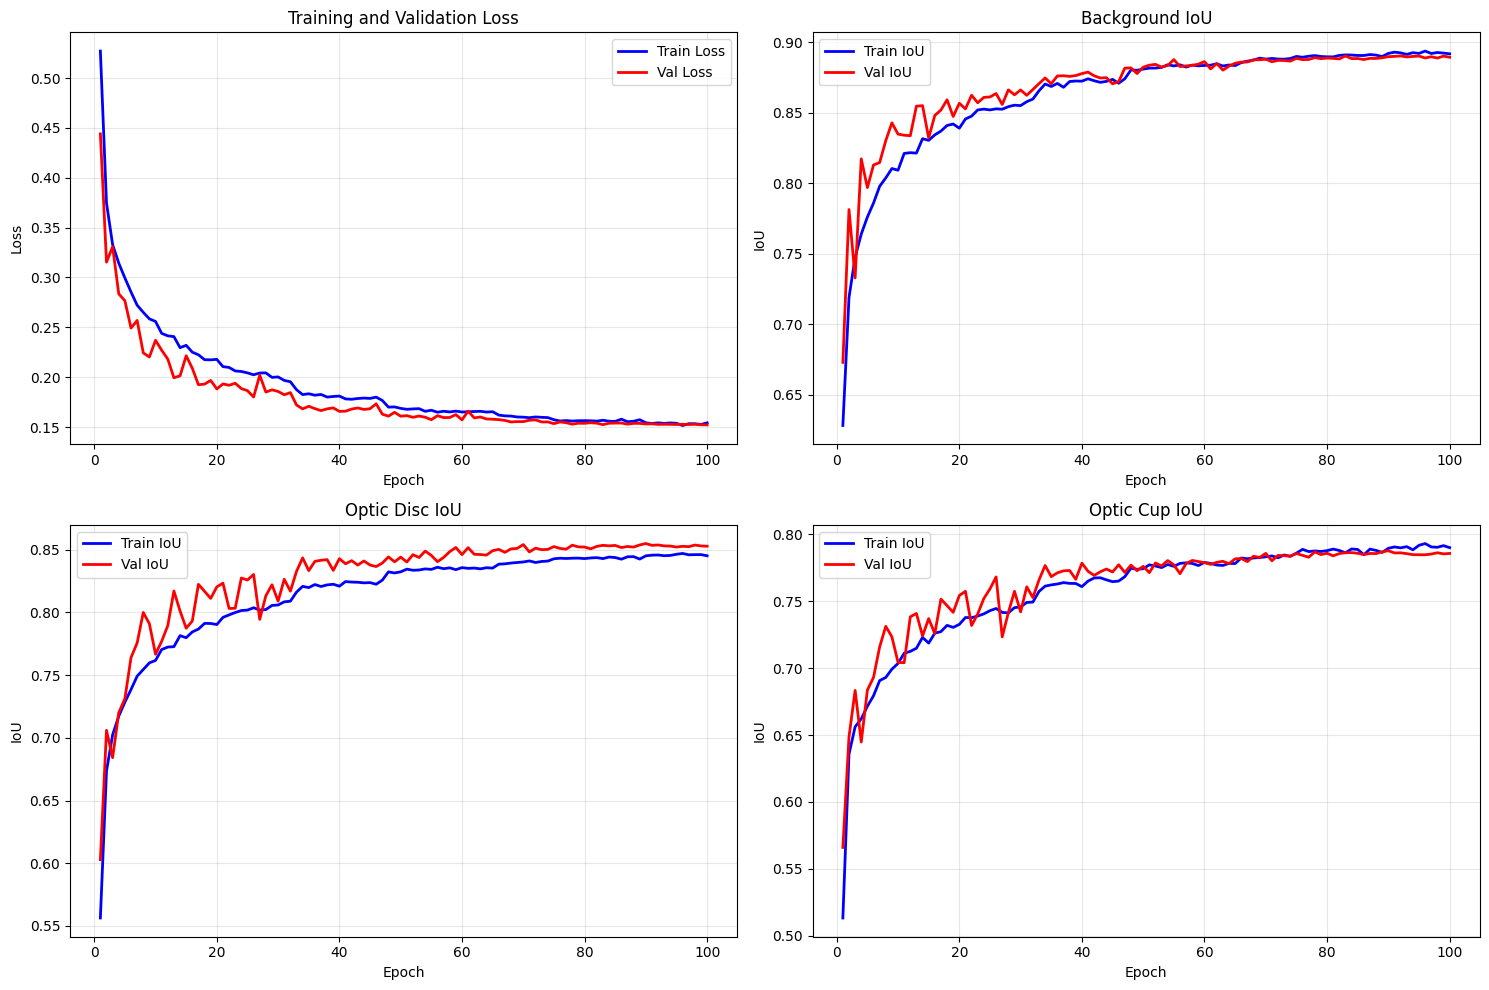

In [5]:
# Plot training history
fig = plot_training_history(
    history, 
    save_path=str(project_root / 'results' / 'training_history.png')
)
plt.show()

## 5. Print Final Metrics

In [6]:
print("\n" + "=" * 80)
print("FINAL TRAINING RESULTS")
print("=" * 80)

final_epoch = len(history['train_loss'])
print(f"\nTotal Epochs: {final_epoch}")

print("\nFinal Training Metrics:")
print(f"  Loss:        {history['train_loss'][-1]:.4f}")
print(f"  IoU (BG):    {history['train_iou_bg'][-1]:.4f}")
print(f"  IoU (Disc):  {history['train_iou_disc'][-1]:.4f}")
print(f"  IoU (Cup):   {history['train_iou_cup'][-1]:.4f}")

print("\nFinal Validation Metrics:")
print(f"  Loss:        {history['val_loss'][-1]:.4f}")
print(f"  IoU (BG):    {history['val_iou_bg'][-1]:.4f}")
print(f"  IoU (Disc):  {history['val_iou_disc'][-1]:.4f}")
print(f"  IoU (Cup):   {history['val_iou_cup'][-1]:.4f}")

print("\nBest Validation Loss:")
best_epoch = history['val_loss'].index(min(history['val_loss'])) + 1
best_val_loss = min(history['val_loss'])
print(f"  Epoch: {best_epoch}")
print(f"  Loss:  {best_val_loss:.4f}")

print("\n" + "=" * 80)


FINAL TRAINING RESULTS

Total Epochs: 100

Final Training Metrics:
  Loss:        0.1543
  IoU (BG):    0.8918
  IoU (Disc):  0.8452
  IoU (Cup):   0.7901

Final Validation Metrics:
  Loss:        0.1522
  IoU (BG):    0.8893
  IoU (Disc):  0.8529
  IoU (Cup):   0.7858

Best Validation Loss:
  Epoch: 100
  Loss:  0.1522



## 6. Save Training History

In [7]:
import json

# Save history as JSON
results_dir = project_root / 'results'
results_dir.mkdir(exist_ok=True, parents=True)

history_path = results_dir / 'training_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)

print(f"Training history saved to: {history_path}")

Training history saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/training_history.json


## 7. Visualize Predictions on Test Images

Using device: cuda
Loading model from /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints/best_model.pth
Loading test dataset...
TEST split: 396 samples
Test dataset size: 396
Sample 78: IoU Disc=0.885, IoU Cup=0.720
Sample 277: IoU Disc=0.907, IoU Cup=0.803
Sample 250: IoU Disc=0.855, IoU Cup=0.878
Sample 55: IoU Disc=0.924, IoU Cup=0.885

Visualization saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/predictions_visualization.png


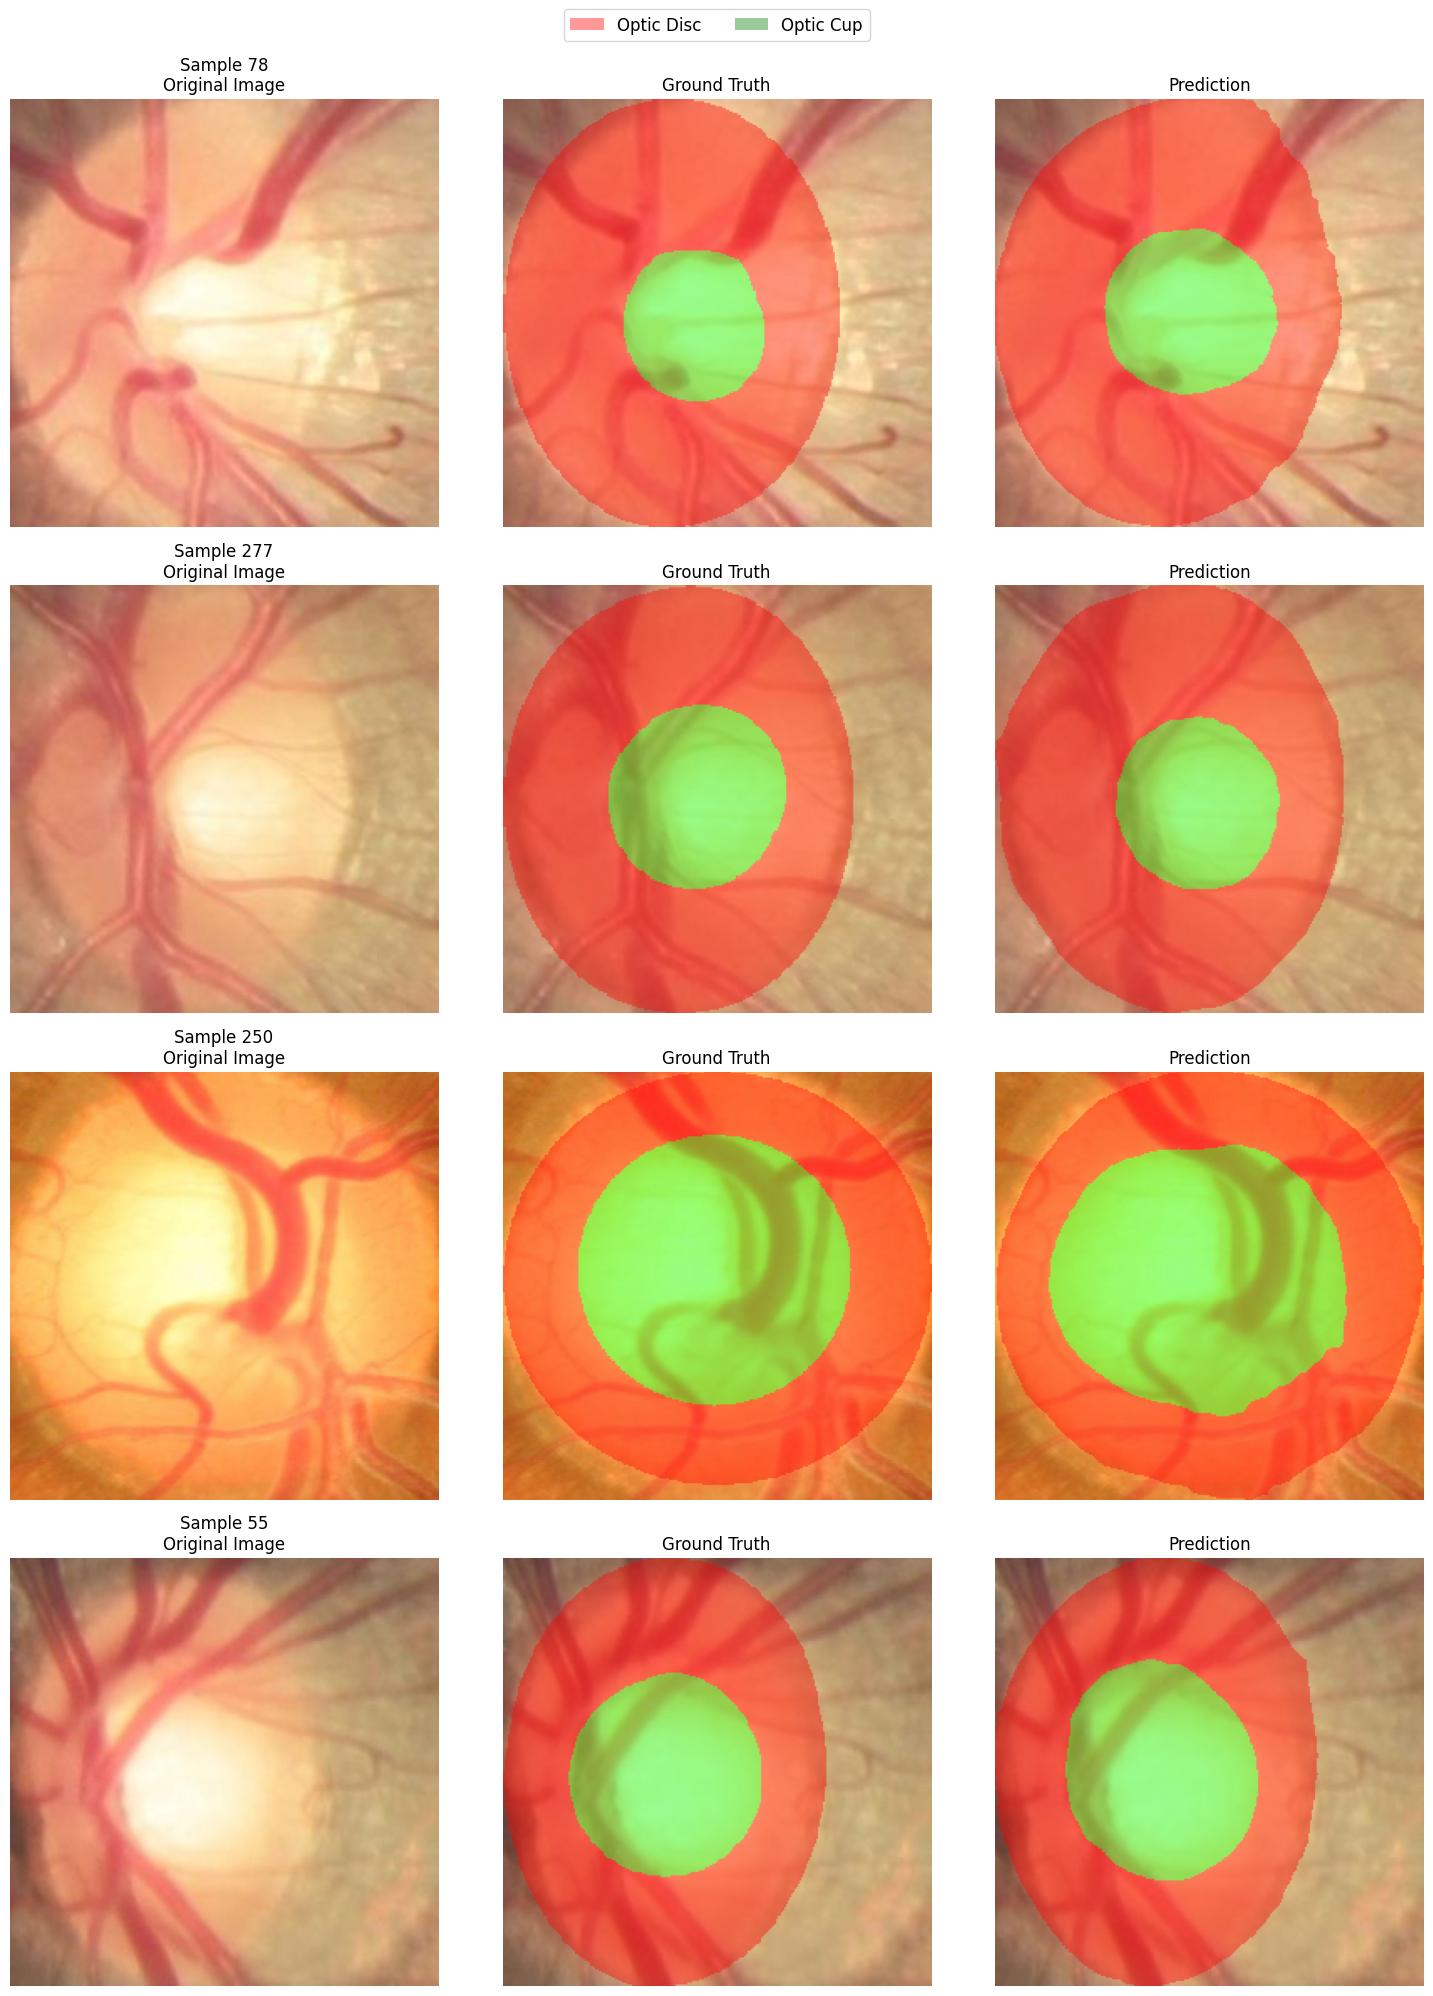

In [8]:
from utils.visualize_predictions import visualize_predictions

# Visualize predictions on test images
fig = visualize_predictions(
    checkpoint_path=str(project_root / 'checkpoints' / 'best_model.pth'),
    root_dir=str(project_root),
    num_samples=4,
    save_path=str(project_root / 'results' / 'predictions_visualization.png'),
    device='cuda' if torch.cuda.is_available() else 'cpu',
    image_size=config['image_size'],
    seed=42
)


## 8. Evaluate on Complete Test Set

In [6]:
from utils.evaluate_test_set import evaluate_test_set

# Evaluate on entire test set
test_results = evaluate_test_set(
    checkpoint_path=str(project_root / 'checkpoints' / 'best_model.pth'),
    root_dir=str(project_root),
    device='cuda' if torch.cuda.is_available() else 'cpu',
    image_size=config['image_size'],
    seed=42,
    save_path=str(project_root / 'results' / 'test_evaluation.json')
)


Using device: cuda
Loading model from /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints/best_model.pth
Loading test dataset...
TEST split: 396 samples
Test dataset size: 396

Evaluating test set...
Loading test dataset...
TEST split: 396 samples
Test dataset size: 396

Evaluating test set...


Evaluating: 100%|██████████| 396/396 [00:05<00:00, 78.05it/s]


TEST SET EVALUATION RESULTS

Test Set Size: 396 images

--- IoU Scores ---
Background:  0.8853 ± 0.0593
Optic Disc:  0.8461 ± 0.0868
Optic Cup:   0.7852 ± 0.1089
Mean IoU:    0.8389

--- Dice Scores ---
Background:  0.9381 ± 0.0353
Optic Disc:  0.9136 ± 0.0656
Optic Cup:   0.8750 ± 0.0776
Mean Dice:   0.9089

--- Pixel Accuracy ---
Overall:     0.9174 ± 0.0455

--- Detailed Statistics ---

Optic Disc IoU:
  Min:    0.0705
  Median: 0.8633
  Max:    0.9446

Optic Cup IoU:
  Min:    0.2281
  Median: 0.8116
  Max:    0.9477


Results saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/test_evaluation.json


## 9. Visualize Worst Predictions (Failure Cases)

Using device: cuda
Loading model from /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints/best_model.pth
Loading test dataset...
Filtering incomplete masks...
  Filtered out 234 images with incomplete masks
TEST split: 396 samples
Test dataset size: 396

Evaluating all samples to find worst cup predictions...


Evaluating: 100%|██████████| 396/396 [00:05<00:00, 76.49it/s]


Sample 52: Disc IoU=0.266, Cup IoU=0.228
Sample 209: Disc IoU=0.743, Cup IoU=0.288
Sample 366: Disc IoU=0.071, Cup IoU=0.308
Sample 224: Disc IoU=0.829, Cup IoU=0.377
Sample 86: Disc IoU=0.701, Cup IoU=0.448
Sample 150: Disc IoU=0.701, Cup IoU=0.449
Sample 332: Disc IoU=0.665, Cup IoU=0.465
Sample 44: Disc IoU=0.727, Cup IoU=0.484

Visualization saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/worst_predictions_cup.png


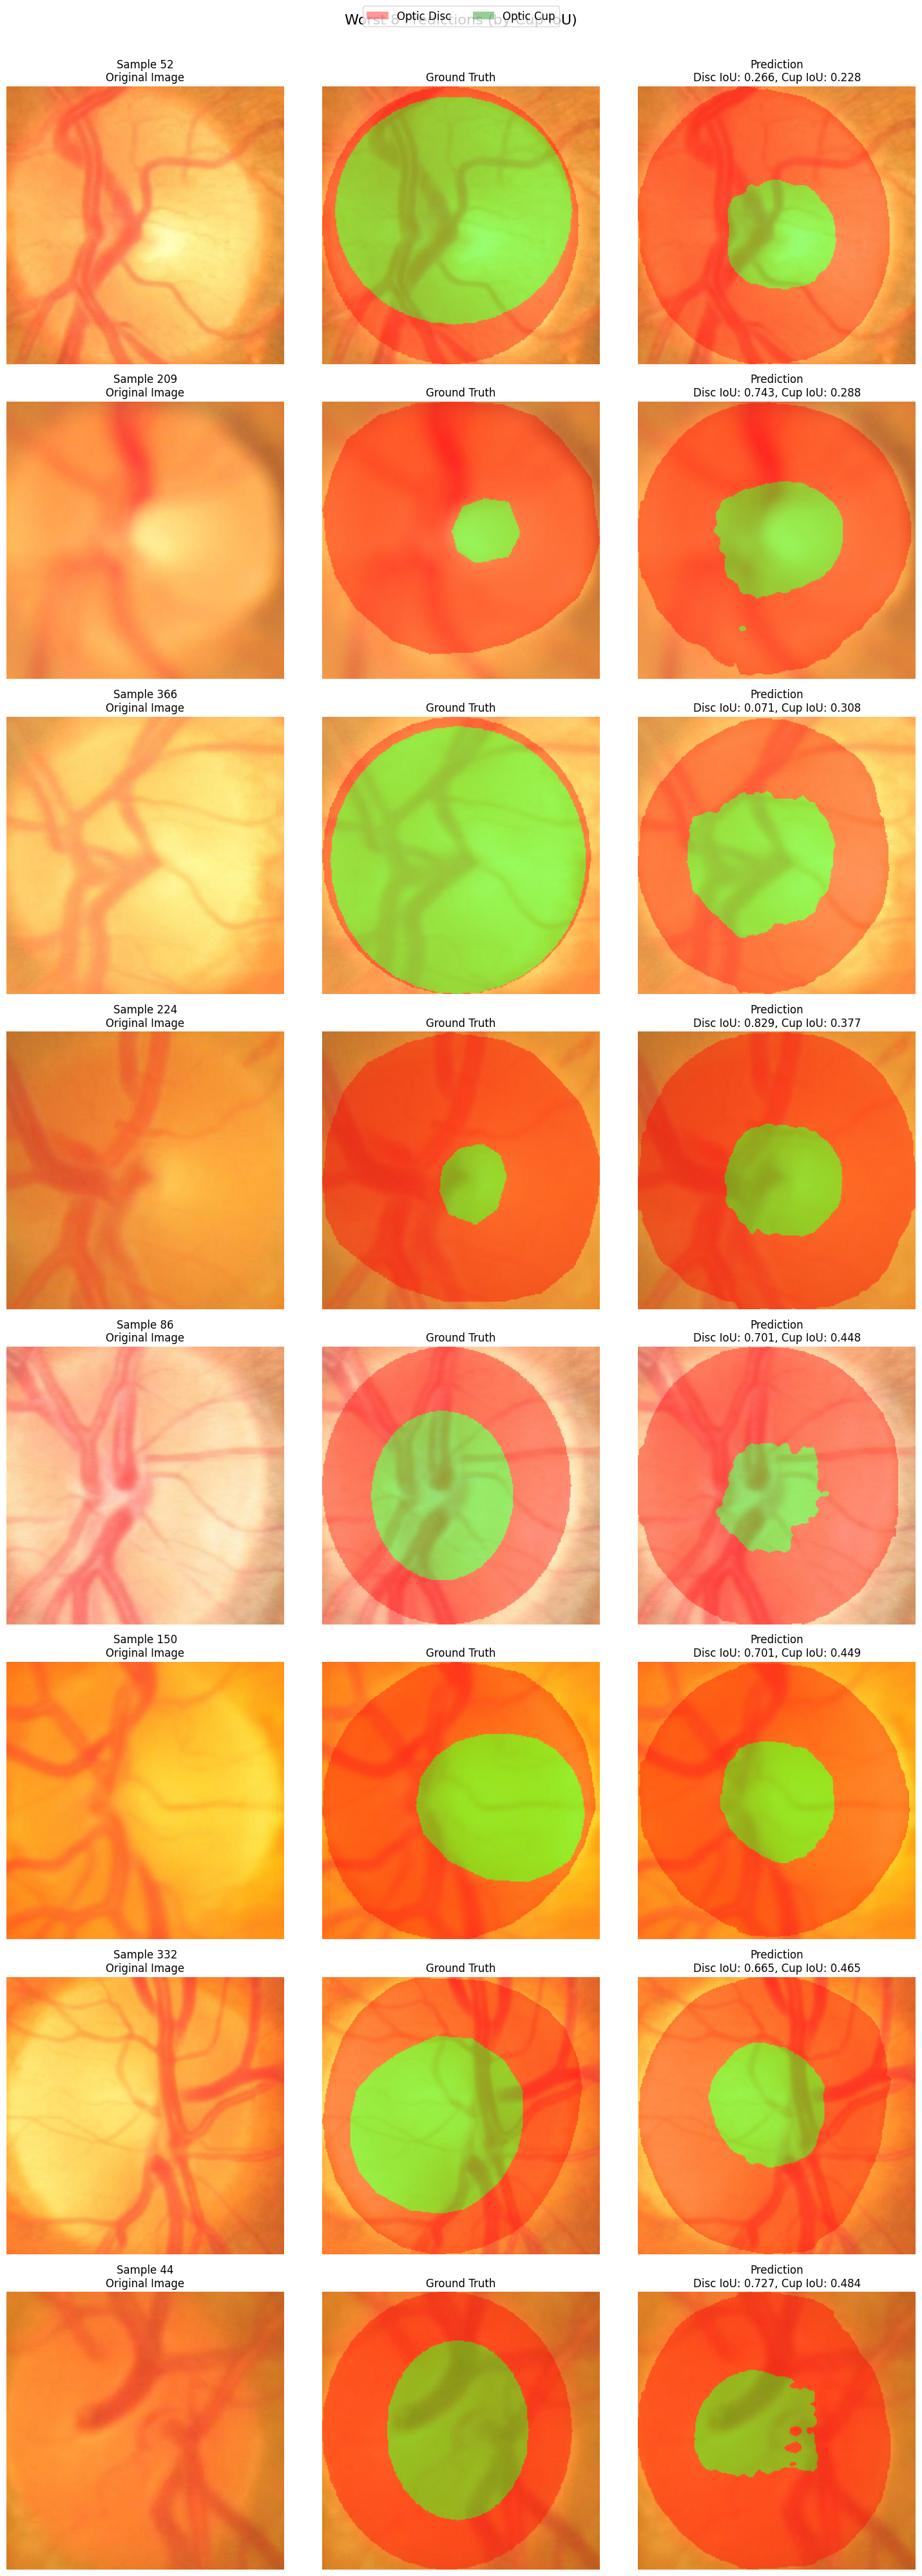

In [5]:
from utils.visualize_worst_predictions import visualize_worst_predictions

# Visualize worst predictions based on Cup IoU
fig_worst, worst_samples = visualize_worst_predictions(
    checkpoint_path=str(project_root / 'checkpoints' / 'best_model.pth'),
    root_dir=str(project_root),
    num_worst=8,
    metric='cup',  # Can be 'cup', 'disc', or 'mean'
    save_path=str(project_root / 'results' / 'worst_predictions_cup.png'),
    device='cuda' if torch.cuda.is_available() else 'cpu',
    image_size=config['image_size'],
    seed=42
)
